# 04 — Evaluation: Quantifying Synthetic Data Fidelity

## Objective
Load the aggregated OLS metrics from `aggregated_model_metrics.parquet` and compute
three evaluation measures for every (method × var_type × N × p × ρ × σ² × iter) scenario:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Coefficient Euclidean Distance** | $\sqrt{\sum_j (\hat{\beta}_{OD,j} - \hat{\beta}_{SD,j})^2}$ | How far the SD coefficients are from the OD coefficients |
| **Significance Agreement** | % of variables where OD & SD agree on $p < 0.05$ | Preservation of inferential conclusions |
| **$R^2$ Degradation** | $|R^2_{adj,OD} - R^2_{adj,SD}|$ | Loss of explanatory power |

## Visualisations (publication-ready, 300 DPI)
1. **Plot 1 — Core Thesis Discovery**: Coefficient Euclidean Distance by method × var_type
2. **Plot 2 — Impact of N and p**: $R^2$ degradation across sample size and dimensionality
3. **Plot 3 — Multicollinearity (ρ)**: Error rates vs. correlation level

In [1]:
# ── Imports & Config ─────────────────────────────────────────────────────────
import os, gc, json, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

# ── Load simulation config (single source of truth) ─────────────────────────
config_path = os.path.join("..", "config", "config.json")
with open(config_path) as f:
    config = json.load(f)

N_VALS      = sorted(config["simulation"]["N"])
P_VALS      = sorted(config["simulation"]["p"])
VAR_TYPES   = sorted(config["simulation"]["var_type"])          # e.g. ["binary", "continuous"]
METHODS     = sorted(config["synthesis"]["methods"])             # e.g. ["cart", "norm", "pmm"]
RHO_VALS    = sorted([float(r) for r in config["parameters"]["rho"]])
SIGMA2_VALS = sorted([float(s) for s in config["parameters"]["sigma_2"]])
BETA_TRUE   = config["parameters"]["beta"]

# ── Publication-quality style ─────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
})

# ── Auto-scaling colour palettes ─────────────────────────────────────────────
# Fixed colours for known keys; auto-extends for new ones via a broad palette.
_FIXED_METHOD_COLORS = {"cart": "#e74c3c", "norm": "#2ecc71", "pmm": "#3498db"}
_FIXED_VTYPE_COLORS  = {"binary": "#3498db", "continuous": "#e74c3c"}
_EXTRA_COLORS = ["#f39c12", "#9b59b6", "#1abc9c", "#e67e22", "#34495e", "#e91e63", "#00bcd4", "#8bc34a"]

def _build_palette(keys, fixed_map, extra_pool):
    """Assign fixed colours to known keys, auto-extend for new ones."""
    palette, extra_idx = {}, 0
    for k in keys:
        if k in fixed_map:
            palette[k] = fixed_map[k]
        else:
            palette[k] = extra_pool[extra_idx % len(extra_pool)]
            extra_idx += 1
    return palette

METHOD_PALETTE = {k.upper(): v for k, v in _build_palette(METHODS, _FIXED_METHOD_COLORS, _EXTRA_COLORS).items()}
METHOD_ORDER   = [m.upper() for m in METHODS]

VARTYPE_PALETTE = {k.capitalize(): v for k, v in _build_palette(VAR_TYPES, _FIXED_VTYPE_COLORS, _EXTRA_COLORS).items()}
VARTYPE_ORDER   = [v.capitalize() for v in VAR_TYPES]

result_dir = os.path.join("..", "results")
fig_dir    = os.path.join(result_dir, "figures")
os.makedirs(fig_dir, exist_ok=True)

print(f"Config loaded — {len(METHODS)} methods × {len(VAR_TYPES)} var_types")
print(f"  N:      {N_VALS}")
print(f"  p:      {P_VALS}")
print(f"  ρ:      {RHO_VALS}")
print(f"  σ²:     {SIGMA2_VALS}")
print(f"  Methods:   {METHOD_ORDER}")
print(f"  Var types: {VARTYPE_ORDER}")
print("Ready.")

Config loaded — 3 methods × 2 var_types
  N:      [100, 1000]
  p:      [3, 10]
  ρ:      [0.0, 0.3, 0.6]
  σ²:     [1.0, 1.5, 2.0]
  Methods:   ['CART', 'NORM', 'PMM']
  Var types: ['Binary', 'Continuous']
Ready.


In [ ]:
# ── Load Parquet ─────────────────────────────────────────────────────────────
parquet_path = os.path.join(result_dir, "aggregated_model_metrics.parquet")
df = pd.read_parquet(parquet_path)
print(f"Loaded {len(df):,} rows × {len(df.columns)} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# ── Fix float precision: R writes 0.3 as 0.2999999... in parquet ────────────
# Round to 6 dp so pivot-table index lookups match the config values exactly.
df["rho"]     = df["rho"].round(6)
df["sigma_2"] = df["sigma_2"].round(6)

# Re-derive axis values from actual data (overrides config-based lists)
RHO_VALS    = sorted(df["rho"].dropna().unique())
SIGMA2_VALS = sorted(df["sigma_2"].dropna().unique())
print(f"Unique ρ in data:   {RHO_VALS}")
print(f"Unique σ² in data:  {SIGMA2_VALS}")
df.head(2)

Loaded 2,160 rows × 75 columns
Memory: 1.3 MB


,method,var_type,N,p,rho,sigma_2,iter,adj_r2_od,adj_r2_sd,beta_od_0,...,pval_sd_1,pval_sd_2,pval_sd_3,pval_sd_4,pval_sd_5,pval_sd_6,pval_sd_7,pval_sd_8,pval_sd_9,pval_sd_10
0,cart,binary,100,3,0.0,1.0,1,0.421618,0.526762,0.757839,...,0.000005,5.638543e-08,0.000001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,cart,binary,100,3,0.0,1.0,2,0.423451,0.456644,1.036154,...,0.000144,1.416738e-08,0.000050,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Compute Evaluation Metrics

### 1. Coefficient Euclidean Distance
$$d(\hat{\beta}_{OD}, \hat{\beta}_{SD}) = \sqrt{\sum_{j=0}^{p} (\hat{\beta}_{OD,j} - \hat{\beta}_{SD,j})^2}$$

This measures how far the entire coefficient vector of the synthetic model has
drifted from the original. We include the intercept ($j=0$).

### 2. Significance Agreement
For each predictor $X_j$, both models either reject or fail to reject $H_0: \beta_j = 0$
at $\alpha = 0.05$. The agreement rate is the percentage of predictors where both
models reach the **same conclusion**.

### 3. $R^2$ Degradation
$$\Delta R^2 = |R^2_{adj,OD} - R^2_{adj,SD}|$$

This measures how much explanatory power is lost when training on synthetic data.

In [3]:
# ── Identify coefficient columns ────────────────────────────────────────────
beta_od_cols = [c for c in df.columns if c.startswith("beta_od_")]
beta_sd_cols = [c for c in df.columns if c.startswith("beta_sd_")]
pval_od_cols = [c for c in df.columns if c.startswith("pval_od_")]
pval_sd_cols = [c for c in df.columns if c.startswith("pval_sd_")]

print(f"Coefficient columns: {len(beta_od_cols)} (OD) / {len(beta_sd_cols)} (SD)")
print(f"P-value columns:     {len(pval_od_cols)} (OD) / {len(pval_sd_cols)} (SD)")

Coefficient columns: 11 (OD) / 11 (SD)
P-value columns:     11 (OD) / 11 (SD)


In [4]:
# ── 1. Coefficient Euclidean Distance ───────────────────────────────────────
beta_od_arr = df[beta_od_cols].values  # (n_rows, 11)
beta_sd_arr = df[beta_sd_cols].values

# NaN-aware: np.nansum treats NaN positions (from p=3 padding) as 0 difference
df["coef_eucl_dist"] = np.sqrt(np.nansum((beta_od_arr - beta_sd_arr) ** 2, axis=1))

print("Coefficient Euclidean Distance — summary by method:")
print(df.groupby("method")["coef_eucl_dist"].describe().round(3))

Coefficient Euclidean Distance — summary by method:
        count   mean    std    min    25%    50%    75%    max
method                                                        
cart    720.0  1.342  1.310  0.026  0.331  0.914  1.834  7.000
norm    720.0  0.669  0.629  0.016  0.216  0.451  0.913  3.573
pmm     720.0  0.549  0.526  0.025  0.186  0.379  0.720  3.395


In [5]:
# ── 2. Significance Agreement ───────────────────────────────────────────────
#
# For each row, count how many predictors (excluding intercept at index 0)
# have MATCHING significance decisions at α = 0.05.
#   sig_od_j = (pval_od_j < 0.05)
#   sig_sd_j = (pval_sd_j < 0.05)
#   agreement_j = (sig_od_j == sig_sd_j)
#   significance_agreement = mean(agreement_j) * 100

# Use only slope p-values (indices 1..p), skip intercept
pval_od_arr = df[pval_od_cols[1:]].values  # skip pval_od_0 (intercept)
pval_sd_arr = df[pval_sd_cols[1:]].values

sig_od = pval_od_arr < 0.05
sig_sd = pval_sd_arr < 0.05

# Where both are NaN (padding for p=3), that's not a real predictor — mask it
valid_mask = ~(np.isnan(pval_od_arr) & np.isnan(pval_sd_arr))
agreement  = (sig_od == sig_sd) & valid_mask

n_valid = valid_mask.sum(axis=1)
n_agree = agreement.sum(axis=1)

df["sig_agreement_pct"] = np.where(n_valid > 0, (n_agree / n_valid) * 100, np.nan)

print("Significance Agreement (%) — summary by method:")
print(df.groupby("method")["sig_agreement_pct"].describe().round(2))

Significance Agreement (%) — summary by method:
        count   mean    std    min    25%    50%    75%    max
method                                                        
cart    720.0  81.32  27.96   0.00   60.0  100.0  100.0  100.0
norm    720.0  94.96  12.46  33.33  100.0  100.0  100.0  100.0
pmm     720.0  94.30  12.94  33.33  100.0  100.0  100.0  100.0


In [6]:
# ── 3. R² Degradation ───────────────────────────────────────────────────────
df["r2_degradation"] = (df["adj_r2_od"] - df["adj_r2_sd"]).abs()

print("R² Degradation — summary by method:")
print(df.groupby("method")["r2_degradation"].describe().round(4))

R² Degradation — summary by method:
        count    mean     std     min     25%     50%     75%     max
method                                                               
cart    720.0  0.1516  0.1535  0.0001  0.0372  0.1011  0.2172  0.7434
norm    720.0  0.0332  0.0393  0.0000  0.0074  0.0201  0.0449  0.3210
pmm     720.0  0.0299  0.0414  0.0001  0.0052  0.0162  0.0377  0.3573


In [7]:
# ── Save enriched DataFrame ─────────────────────────────────────────────────
enriched_path = os.path.join(result_dir, "evaluation_metrics.parquet")
df.to_parquet(enriched_path, index=False)
print(f"✓ Saved enriched metrics to: {enriched_path}")
print(f"  Columns added: coef_eucl_dist, sig_agreement_pct, r2_degradation")

# Free memory from large arrays
del beta_od_arr, beta_sd_arr, pval_od_arr, pval_sd_arr, sig_od, sig_sd
gc.collect()

df.head(3)

✓ Saved enriched metrics to: ../results/evaluation_metrics.parquet
  Columns added: coef_eucl_dist, sig_agreement_pct, r2_degradation


,method,var_type,N,p,rho,sigma_2,iter,adj_r2_od,adj_r2_sd,beta_od_0,...,pval_sd_4,pval_sd_5,pval_sd_6,pval_sd_7,pval_sd_8,pval_sd_9,pval_sd_10,coef_eucl_dist,sig_agreement_pct,r2_degradation
0,cart,binary,100,3,0.0,1.0,1,0.421618,0.526762,0.757839,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.293663,100.0,0.105144
1,cart,binary,100,3,0.0,1.0,2,0.423451,0.456644,1.036154,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.524658,100.0,0.033193
2,cart,binary,100,3,0.0,1.0,3,0.344862,0.245625,1.530673,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.298921,100.0,0.099237


---

## Plot 1 — Core Thesis Discovery

**Research question:** Does CART fail to preserve regression coefficients for
continuous predictors while performing well for binary predictors?

A grouped boxplot of **Coefficient Euclidean Distance** across the 3 synthesis
methods, faceted by `var_type`, directly tests this hypothesis.  
If CART's distribution is dramatically higher for `continuous` but comparable to
NORM / PMM for `binary`, the thesis finding is confirmed.

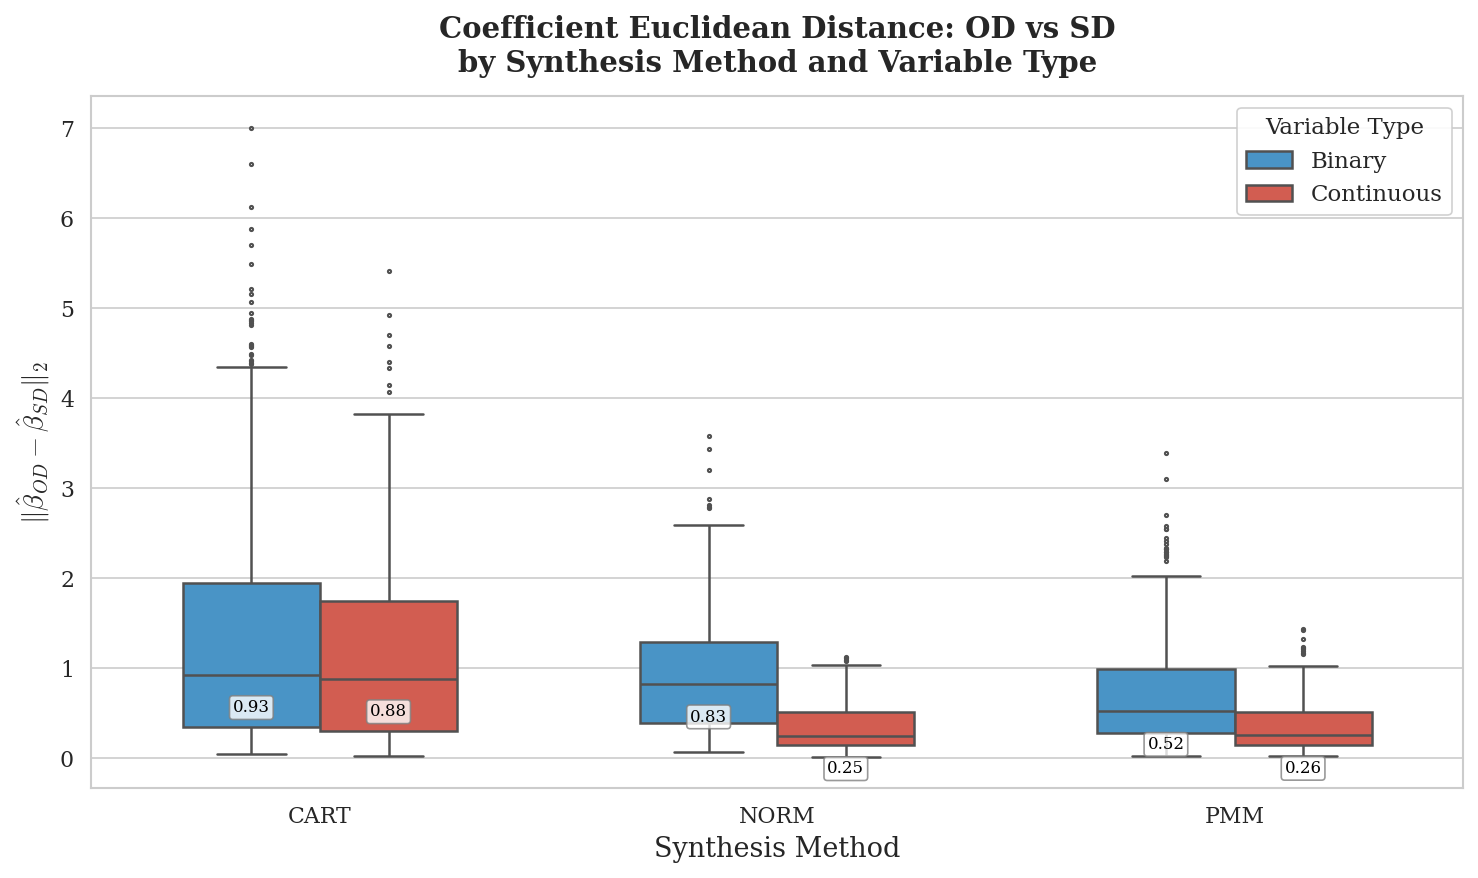

✓ Plot 1 saved.


In [8]:
# ── Plot 1: Coefficient Euclidean Distance by Method × var_type ─────────────

plot_df = df.dropna(subset=["coef_eucl_dist"]).copy()
plot_df["Method"] = plot_df["method"].str.upper()
plot_df["Variable Type"] = plot_df["var_type"].str.capitalize()

fig, ax = plt.subplots(figsize=(max(10, 3 * len(METHODS)), 6))

sns.boxplot(
    data=plot_df,
    x="Method",
    y="coef_eucl_dist",
    hue="Variable Type",
    order=METHOD_ORDER,
    hue_order=VARTYPE_ORDER,
    palette=VARTYPE_PALETTE,
    fliersize=1.5,
    linewidth=1.2,
    width=0.6,
    ax=ax,
)

ax.set_title("Coefficient Euclidean Distance: OD vs SD\n"
             "by Synthesis Method and Variable Type",
             fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel(r"$\|\hat{\beta}_{OD} - \hat{\beta}_{SD}\|_2$", fontsize=13)
ax.set_xlabel("Synthesis Method", fontsize=13)
ax.legend(title="Variable Type", fontsize=11, title_fontsize=11, framealpha=0.9)

# Add median annotations
n_vtypes = len(VARTYPE_ORDER)
for i, method in enumerate(METHOD_ORDER):
    for j, vtype in enumerate(VARTYPE_ORDER):
        subset = plot_df[(plot_df["Method"] == method) & (plot_df["Variable Type"] == vtype)]
        if subset.empty:
            continue
        median_val = subset["coef_eucl_dist"].median()
        x_pos = i + (j - (n_vtypes - 1) / 2) * (0.6 / n_vtypes)
        ax.annotate(f"{median_val:.2f}",
                    xy=(x_pos, median_val),
                    xytext=(0, -18), textcoords="offset points",
                    fontsize=8, ha="center", color="black",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()
fig.savefig(os.path.join(fig_dir, "plot1_core_thesis_coef_distance.png"))
plt.show()
print("✓ Plot 1 saved.")

---

## Plot 2 — Impact of Sample Size (N) and Dimensionality (p)

**Research question:** How does $R^2$ degradation behave when $N$ and $p$ change?

A 2×2 facet grid (rows = $N$, columns = $p$) with grouped boxplots by method
shows whether:
- Larger $N$ reduces degradation (more data → better synthesis)
- Higher $p$ increases degradation (curse of dimensionality for synthesis)

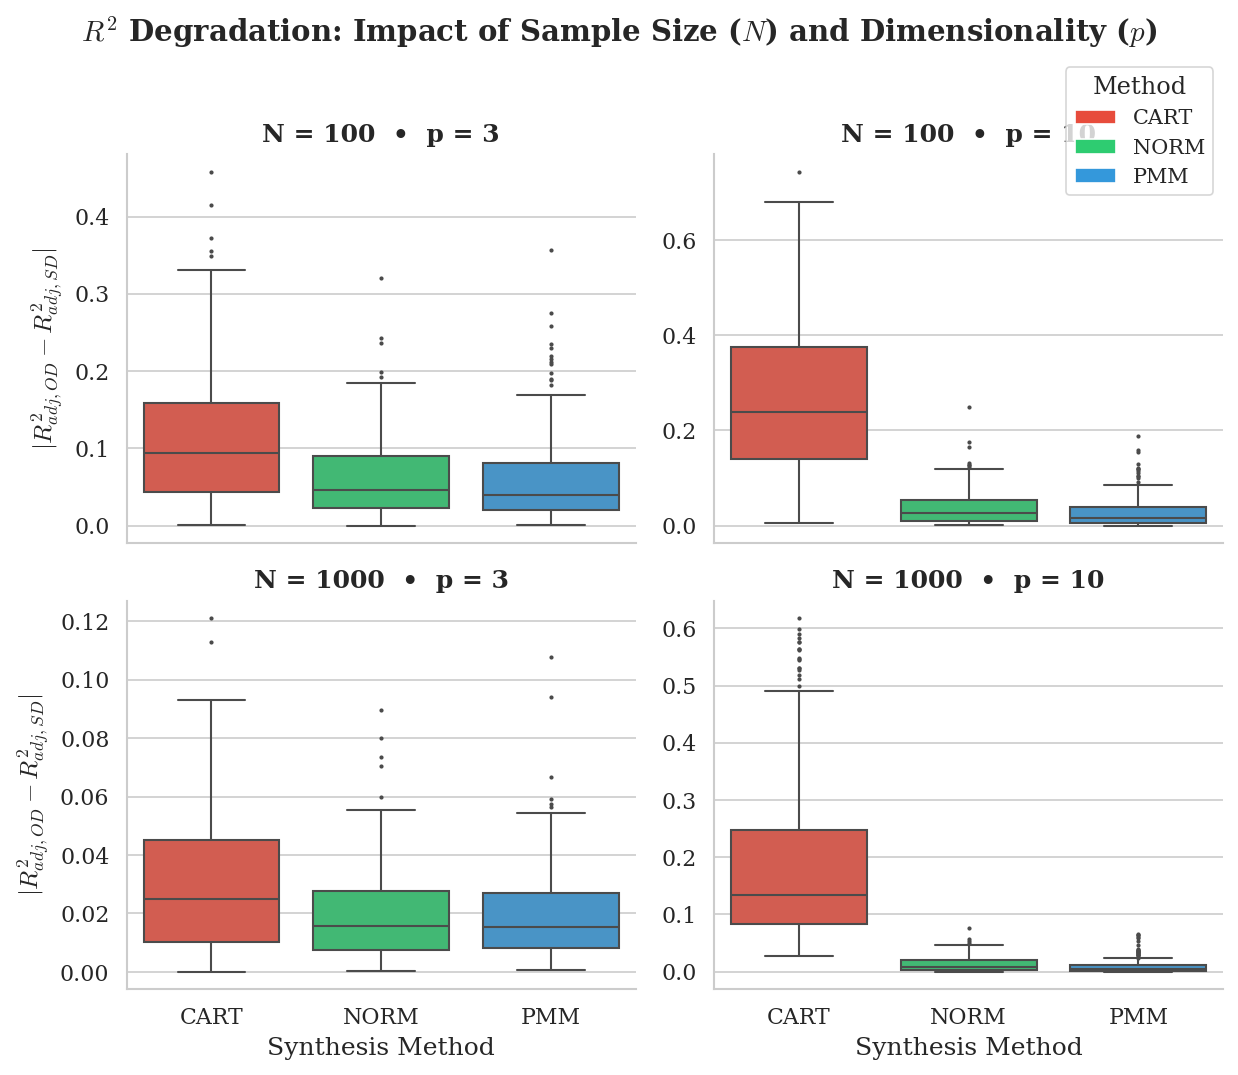

✓ Plot 2 saved.


In [9]:
# ── Plot 2: R² Degradation by N × p (facet grid) ───────────────────────────

plot_df2 = df.dropna(subset=["r2_degradation"]).copy()
plot_df2["Method"] = plot_df2["method"].str.upper()
plot_df2["N_label"] = "N = " + plot_df2["N"].astype(str)
plot_df2["p_label"] = "p = " + plot_df2["p"].astype(str)

N_label_order = [f"N = {n}" for n in N_VALS]
p_label_order = [f"p = {p}" for p in P_VALS]

g = sns.catplot(
    data=plot_df2,
    x="Method",
    y="r2_degradation",
    hue="Method",
    col="p_label",
    row="N_label",
    kind="box",
    order=METHOD_ORDER,
    hue_order=METHOD_ORDER,
    palette=METHOD_PALETTE,
    col_order=p_label_order,
    row_order=N_label_order,
    height=3.5,
    aspect=1.2,
    fliersize=1,
    linewidth=1,
    legend=False,
    sharey=False,
)

g.figure.suptitle(r"$R^2$ Degradation: Impact of Sample Size ($N$) and Dimensionality ($p$)",
                  fontsize=14, fontweight="bold", y=1.02)
g.set_axis_labels("Synthesis Method", r"$|R^2_{adj,OD} - R^2_{adj,SD}|$")
g.set_titles("{row_name}  •  {col_name}")

legend_elements = [Patch(facecolor=METHOD_PALETTE[m], label=m) for m in METHOD_ORDER]
g.figure.legend(handles=legend_elements, loc="upper right",
                bbox_to_anchor=(0.98, 0.98), fontsize=10, title="Method")

plt.tight_layout()
g.savefig(os.path.join(fig_dir, "plot2_r2_degradation_N_p.png"))
plt.show()
print("✓ Plot 2 saved.")

---

## Plot 3 — Effect of Multicollinearity (ρ)

**Research question:** How does increasing predictor correlation ($\rho$) affect
each synthesis method's ability to preserve regression coefficients?

A line plot with $\rho$ on the x-axis and **mean Coefficient Euclidean Distance**
on the y-axis, with one line per method.  
Error bands show the 95% CI of the mean across simulation repetitions.

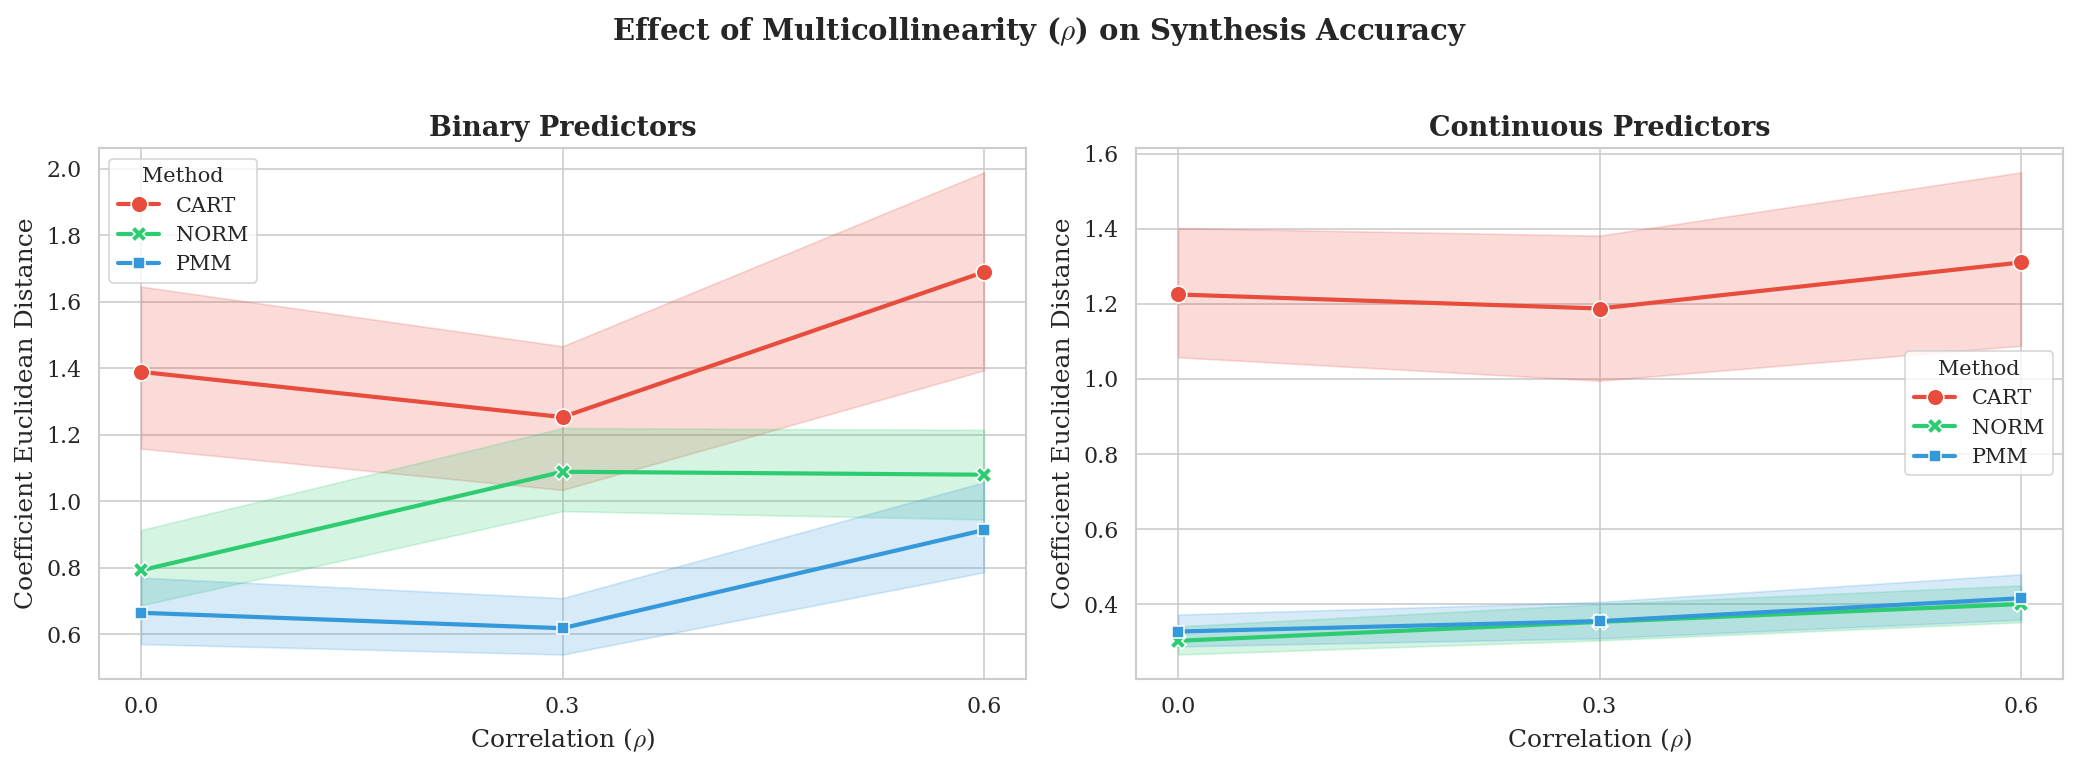

✓ Plot 3 saved.


In [10]:
# ── Plot 3: Coefficient Distance vs. ρ (multicollinearity) ──────────────────

plot_df3 = df.dropna(subset=["coef_eucl_dist"]).copy()
plot_df3["Method"] = plot_df3["method"].str.upper()
plot_df3["Variable Type"] = plot_df3["var_type"].str.capitalize()

n_vtypes = len(VARTYPE_ORDER)
fig, axes = plt.subplots(1, n_vtypes, figsize=(7 * n_vtypes, 5), sharey=False, squeeze=False)
axes = axes.ravel()

for ax, vtype in zip(axes, VARTYPE_ORDER):
    subset = plot_df3[plot_df3["Variable Type"] == vtype]
    
    sns.lineplot(
        data=subset,
        x="rho",
        y="coef_eucl_dist",
        hue="Method",
        hue_order=METHOD_ORDER,
        palette=METHOD_PALETTE,
        style="Method",
        markers=True,
        dashes=False,
        errorbar=("ci", 95),
        linewidth=2,
        markersize=8,
        ax=ax,
    )
    
    ax.set_title(f"{vtype} Predictors", fontsize=13, fontweight="bold")
    ax.set_xlabel(r"Correlation ($\rho$)", fontsize=12)
    ax.set_ylabel(r"Coefficient Euclidean Distance", fontsize=12)
    ax.set_xticks(RHO_VALS)
    ax.legend(title="Method", fontsize=10, title_fontsize=10)

fig.suptitle(r"Effect of Multicollinearity ($\rho$) on Synthesis Accuracy",
             fontsize=14, fontweight="bold", y=1.02)

plt.tight_layout()
fig.savefig(os.path.join(fig_dir, "plot3_multicollinearity_rho.png"))
plt.show()
print("✓ Plot 3 saved.")

---

## Plot 4 — Practical Utility: Significance Agreement Rate

**Research question:** If a researcher uses synthetic data to run inference, will they
draw the same statistical conclusions about which predictors are significant?

A grouped bar chart of the **Significance Agreement Rate** (%) by method, faceted
by `var_type`, reveals whether the synthesis preserves inferential validity.
A dashed reference line at 100 % marks perfect agreement.


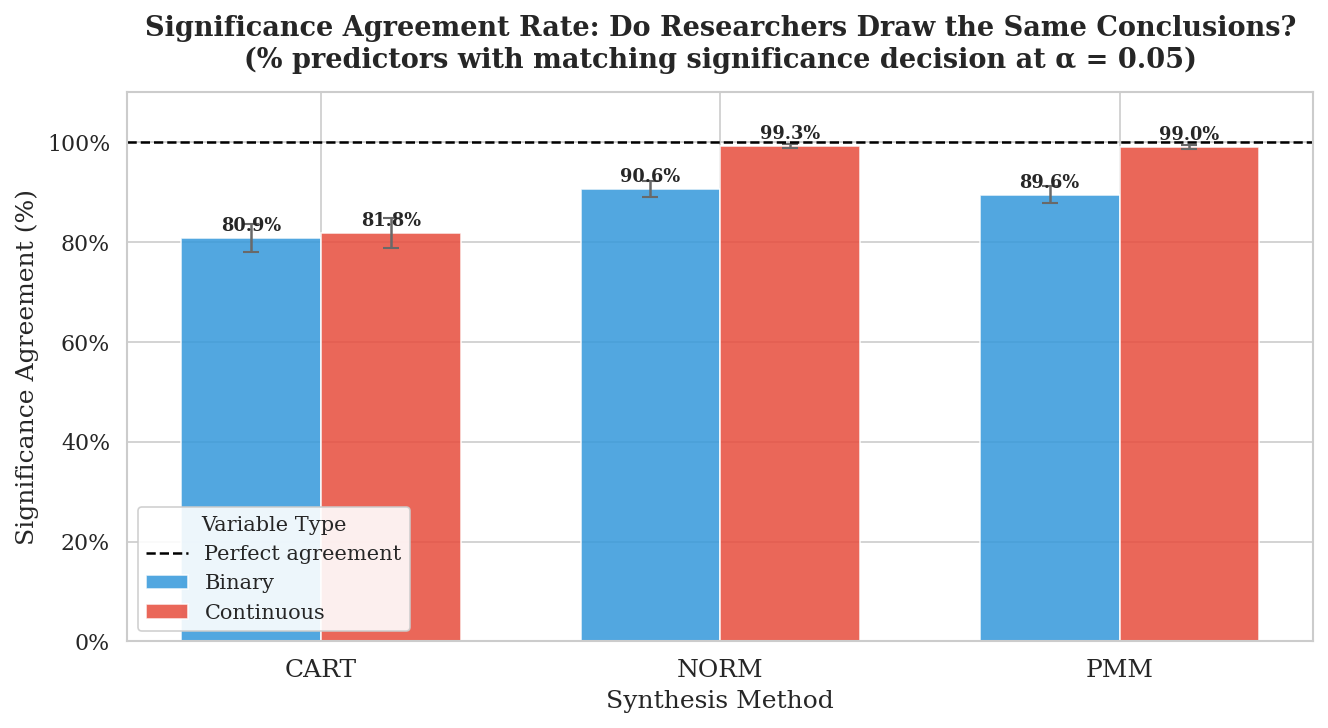

✓ Plot 4 saved.


In [11]:
# ── Plot 4: Significance Agreement Rate by Method × var_type ────────────────

plot_df4 = df.dropna(subset=["sig_agreement_pct"]).copy()
plot_df4["Method"] = plot_df4["method"].str.upper()
plot_df4["Variable Type"] = plot_df4["var_type"].str.capitalize()

# Compute mean ± 95 % CI per (Method, Variable Type)
agg4 = (
    plot_df4.groupby(["Method", "Variable Type"])["sig_agreement_pct"]
    .agg(mean="mean", std="std", count="count")
    .reset_index()
)
agg4["ci95"] = 1.96 * agg4["std"] / agg4["count"].pow(0.5)

n_vtypes = len(VARTYPE_ORDER)
x        = np.arange(len(METHOD_ORDER))
width    = 0.7 / n_vtypes
offsets  = {vt: (i - (n_vtypes - 1) / 2) * width for i, vt in enumerate(VARTYPE_ORDER)}

fig, ax = plt.subplots(figsize=(max(9, 3 * len(METHOD_ORDER)), 5))

for vt in VARTYPE_ORDER:
    subset_agg = agg4[agg4["Variable Type"] == vt].set_index("Method")
    means  = [subset_agg.loc[m, "mean"] if m in subset_agg.index else 0 for m in METHOD_ORDER]
    cis    = [subset_agg.loc[m, "ci95"] if m in subset_agg.index else 0 for m in METHOD_ORDER]
    bars   = ax.bar(
        x + offsets[vt], means, width,
        label=vt, color=VARTYPE_PALETTE[vt],
        alpha=0.85, edgecolor="white", linewidth=0.8,
        yerr=cis, capsize=4, error_kw=dict(linewidth=1.2, ecolor="dimgray"),
    )
    for bar, mean in zip(bars, means):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.6,
            f"{mean:.1f}%",
            ha="center", va="bottom", fontsize=8.5, fontweight="bold",
        )

ax.axhline(100, color="black", linestyle="--", linewidth=1.2, label="Perfect agreement")
ax.set_xticks(x)
ax.set_xticklabels(METHOD_ORDER, fontsize=12)
ax.set_ylim(0, 110)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=100))
ax.set_xlabel("Synthesis Method", fontsize=12)
ax.set_ylabel("Significance Agreement (%)", fontsize=12)
ax.set_title("Significance Agreement Rate: Do Researchers Draw the Same Conclusions?\n"
             "(% predictors with matching significance decision at α = 0.05)",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(title="Variable Type", fontsize=10, title_fontsize=10, framealpha=0.9)

plt.tight_layout()
fig.savefig(os.path.join(fig_dir, "plot4_significance_agreement.png"))
plt.show()
print("✓ Plot 4 saved.")

---

## Plot 5 — Overconfidence: Standard Error Ratio

**Research question:** Do synthesis methods artificially inflate or deflate the
uncertainty of coefficient estimates?

For each predictor slope $j \geq 1$, the **SE Ratio** is
$$\text{SE Ratio}_j = \frac{SE(\hat{\beta}_{SD,j})}{SE(\hat{\beta}_{OD,j})}$$

A ratio below 1 means the synthetic model is *overconfident*; above 1 means it is
*underconfident*. A bold dashed line at `y = 1.0` marks the ideal.


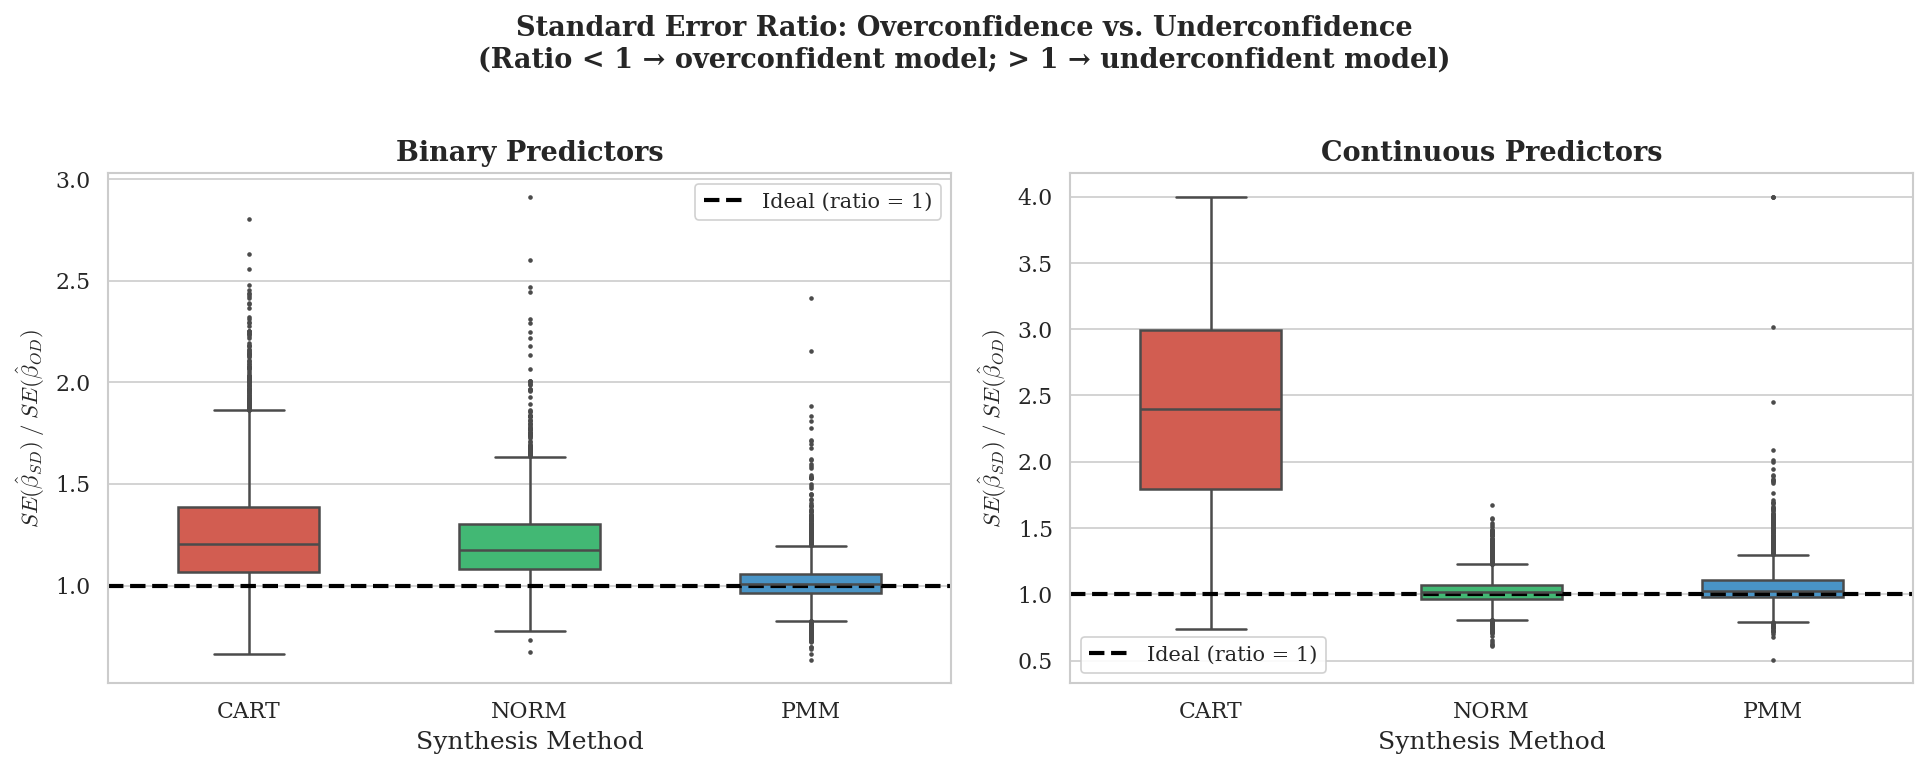

✓ Plot 5 saved.


In [12]:
# ── Plot 5: SE Ratio boxplot by Method × var_type ───────────────────────────

se_od_slope_cols = [c for c in df.columns if c.startswith("se_od_") and c != "se_od_0"]
se_sd_slope_cols = [c for c in df.columns if c.startswith("se_sd_") and c != "se_sd_0"]

se_od_arr = df[se_od_slope_cols].values
se_sd_arr = df[se_sd_slope_cols].values

with np.errstate(divide="ignore", invalid="ignore"):
    se_ratio_arr = np.where(
        (se_od_arr > 0) & ~np.isnan(se_od_arr) & ~np.isnan(se_sd_arr),
        se_sd_arr / se_od_arr,
        np.nan,
    )

n_rows, n_cols = se_ratio_arr.shape
row_idx, col_idx = np.where(~np.isnan(se_ratio_arr))

se_df = pd.DataFrame({
    "se_ratio": se_ratio_arr[row_idx, col_idx],
    "method":   df["method"].values[row_idx],
    "var_type": df["var_type"].values[row_idx],
})
se_df["Method"]        = se_df["method"].str.upper()
se_df["Variable Type"] = se_df["var_type"].str.capitalize()
se_df["se_ratio_capped"] = se_df["se_ratio"].clip(0, 4)

n_vtypes = len(VARTYPE_ORDER)
fig, axes = plt.subplots(1, n_vtypes, figsize=(6.5 * n_vtypes, 5), sharey=False, squeeze=False)
axes = axes.ravel()

for ax, vt in zip(axes, VARTYPE_ORDER):
    subset_se = se_df[se_df["Variable Type"] == vt]
    sns.boxplot(
        data=subset_se,
        x="Method",
        y="se_ratio_capped",
        order=METHOD_ORDER,
        palette=METHOD_PALETTE,
        fliersize=1.2,
        linewidth=1.2,
        width=0.5,
        ax=ax,
    )
    ax.axhline(1.0, color="black", linestyle="--", linewidth=2, label="Ideal (ratio = 1)")
    ax.set_title(f"{vt} Predictors", fontsize=13, fontweight="bold")
    ax.set_xlabel("Synthesis Method", fontsize=12)
    ax.set_ylabel(r"$SE(\hat{\beta}_{SD}) \;/\; SE(\hat{\beta}_{OD})$", fontsize=11)
    ax.legend(fontsize=10, framealpha=0.9)

fig.suptitle("Standard Error Ratio: Overconfidence vs. Underconfidence\n"
             "(Ratio < 1 → overconfident model; > 1 → underconfident model)",
             fontsize=13, fontweight="bold", y=1.02)

plt.tight_layout()
fig.savefig(os.path.join(fig_dir, "plot5_se_ratio.png"))
plt.show()
print("✓ Plot 5 saved.")

---

## Plot 6 — CI Coverage: The Ultimate Validity Test

**Research question:** How often does the synthetic coefficient fall inside the 95 %
confidence interval of the original?

For each slope $j \geq 1$:
$$\text{covered}_j = \mathbb{1}\!\left[\hat{\beta}_{SD,j} \;\in\; \hat{\beta}_{OD,j} \pm 1.96\,SE(\hat{\beta}_{OD,j})\right]$$

Under ideal conditions the coverage **must** be ≥ 95 %. A dramatic drop below this
threshold is mathematical proof that the synthetic data is drawn from a different
population distribution. A reference line is drawn at `y = 0.95`.


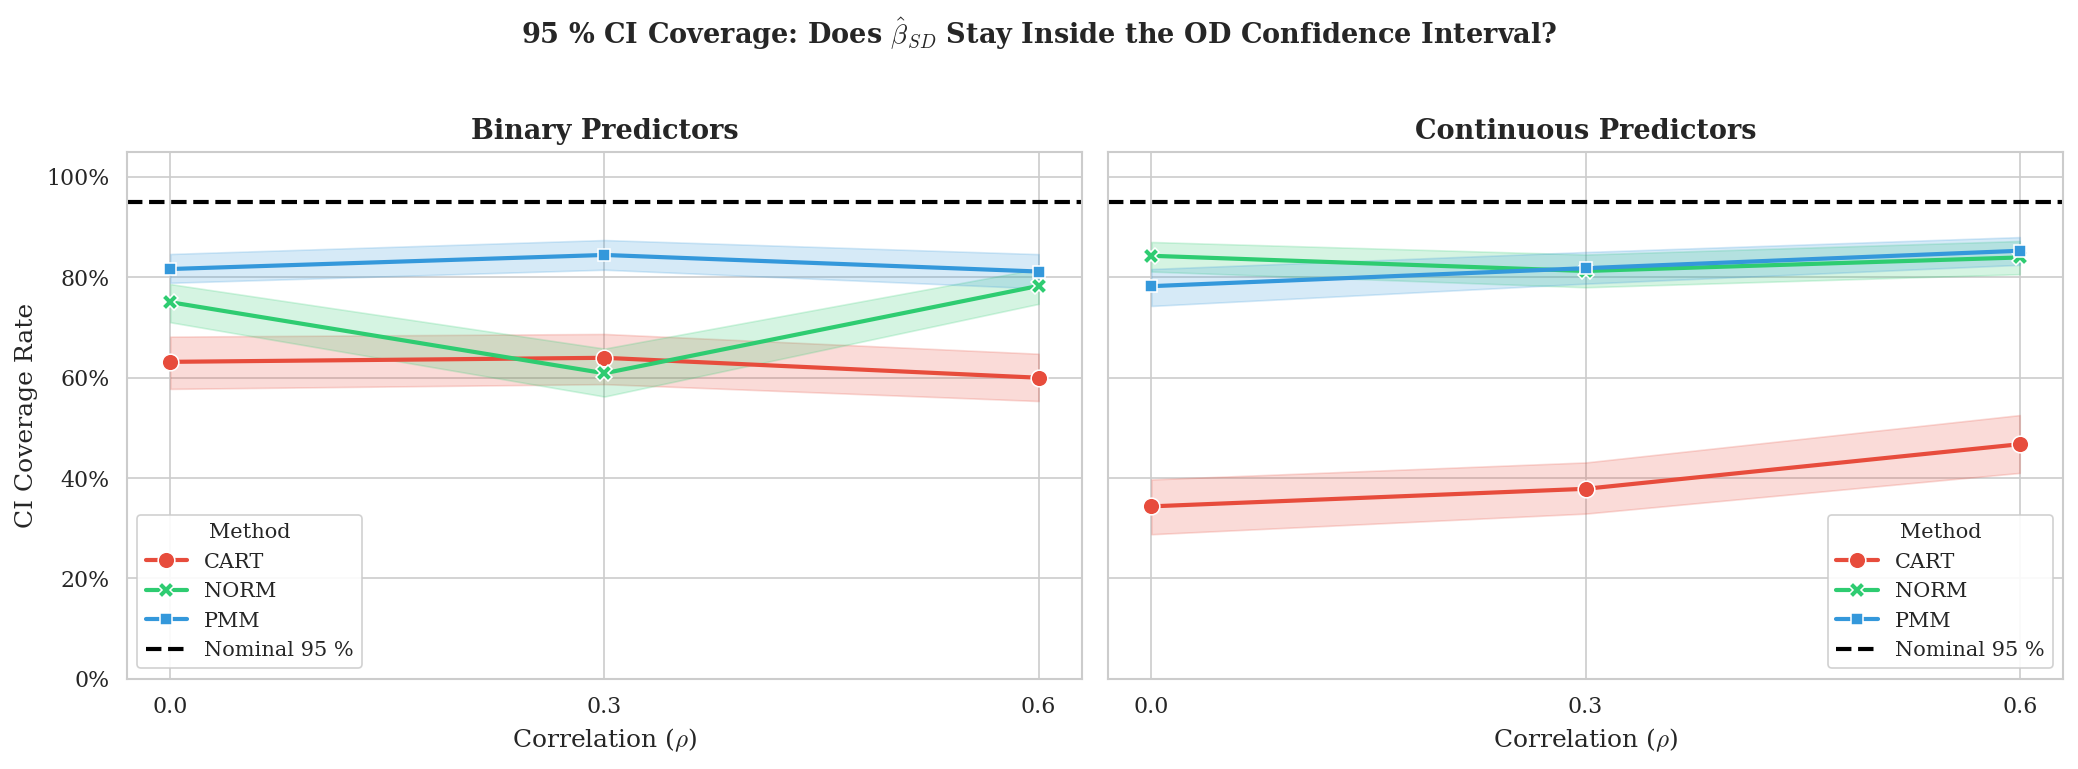

✓ Plot 6 saved.


In [13]:
# ── Plot 6: CI Coverage Rate by Method × var_type ───────────────────────────

beta_od_slope_cols = [c for c in df.columns if c.startswith("beta_od_") and c != "beta_od_0"]
beta_sd_slope_cols = [c for c in df.columns if c.startswith("beta_sd_") and c != "beta_sd_0"]
se_od_slope_cols   = [c for c in df.columns if c.startswith("se_od_")   and c != "se_od_0"]

bo = df[beta_od_slope_cols].values
bs = df[beta_sd_slope_cols].values
so = df[se_od_slope_cols].values

lower = bo - 1.96 * so
upper = bo + 1.96 * so

covered = (bs >= lower) & (bs <= upper)
valid   = ~np.isnan(bo) & ~np.isnan(bs) & ~np.isnan(so) & (so > 0)

n_valid_ci = valid.sum(axis=1)
n_cov_ci   = (covered & valid).sum(axis=1)
df["ci_coverage"] = np.where(n_valid_ci > 0, n_cov_ci / n_valid_ci, np.nan)

cov_df = df.dropna(subset=["ci_coverage"]).copy()
cov_df["Method"]        = cov_df["method"].str.upper()
cov_df["Variable Type"] = cov_df["var_type"].str.capitalize()

n_vtypes = len(VARTYPE_ORDER)
fig, axes = plt.subplots(1, n_vtypes, figsize=(7 * n_vtypes, 5), sharey=True, squeeze=False)
axes = axes.ravel()

for ax, vt in zip(axes, VARTYPE_ORDER):
    subset_cov = cov_df[cov_df["Variable Type"] == vt]
    sns.lineplot(
        data=subset_cov,
        x="rho",
        y="ci_coverage",
        hue="Method",
        hue_order=METHOD_ORDER,
        palette=METHOD_PALETTE,
        style="Method",
        markers=True,
        dashes=False,
        errorbar=("ci", 95),
        linewidth=2,
        markersize=8,
        ax=ax,
    )
    ax.axhline(0.95, color="black", linestyle="--", linewidth=2, label="Nominal 95 %")
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    ax.set_ylim(0, 1.05)
    ax.set_xlabel(r"Correlation ($\rho$)", fontsize=12)
    ax.set_ylabel("CI Coverage Rate", fontsize=12)
    ax.set_title(f"{vt} Predictors", fontsize=13, fontweight="bold")
    ax.set_xticks(RHO_VALS)
    ax.legend(title="Method", fontsize=10, title_fontsize=10, framealpha=0.9)

fig.suptitle(r"95 % CI Coverage: Does $\hat{\beta}_{SD}$ Stay Inside the OD Confidence Interval?",
             fontsize=13, fontweight="bold", y=1.02)

plt.tight_layout()
fig.savefig(os.path.join(fig_dir, "plot6_ci_coverage.png"))
plt.show()
print("✓ Plot 6 saved.")

---

## Plot 7 — Noise Sensitivity: Impact of Error Variance ($\sigma^2$)

**Research question:** Does increasing the inherent noise in the original data
($\sigma^2 \in \{1.0, 1.5, 2.0\}$) amplify synthesis error, or does the extra
noise mask the structural distortions introduced by CART?

A line plot with $\sigma^2$ on the x-axis and **mean Coefficient Euclidean Distance**
on the y-axis (one line per method) per `var_type` panel reveals whether noisy data
is harder to synthesise faithfully.


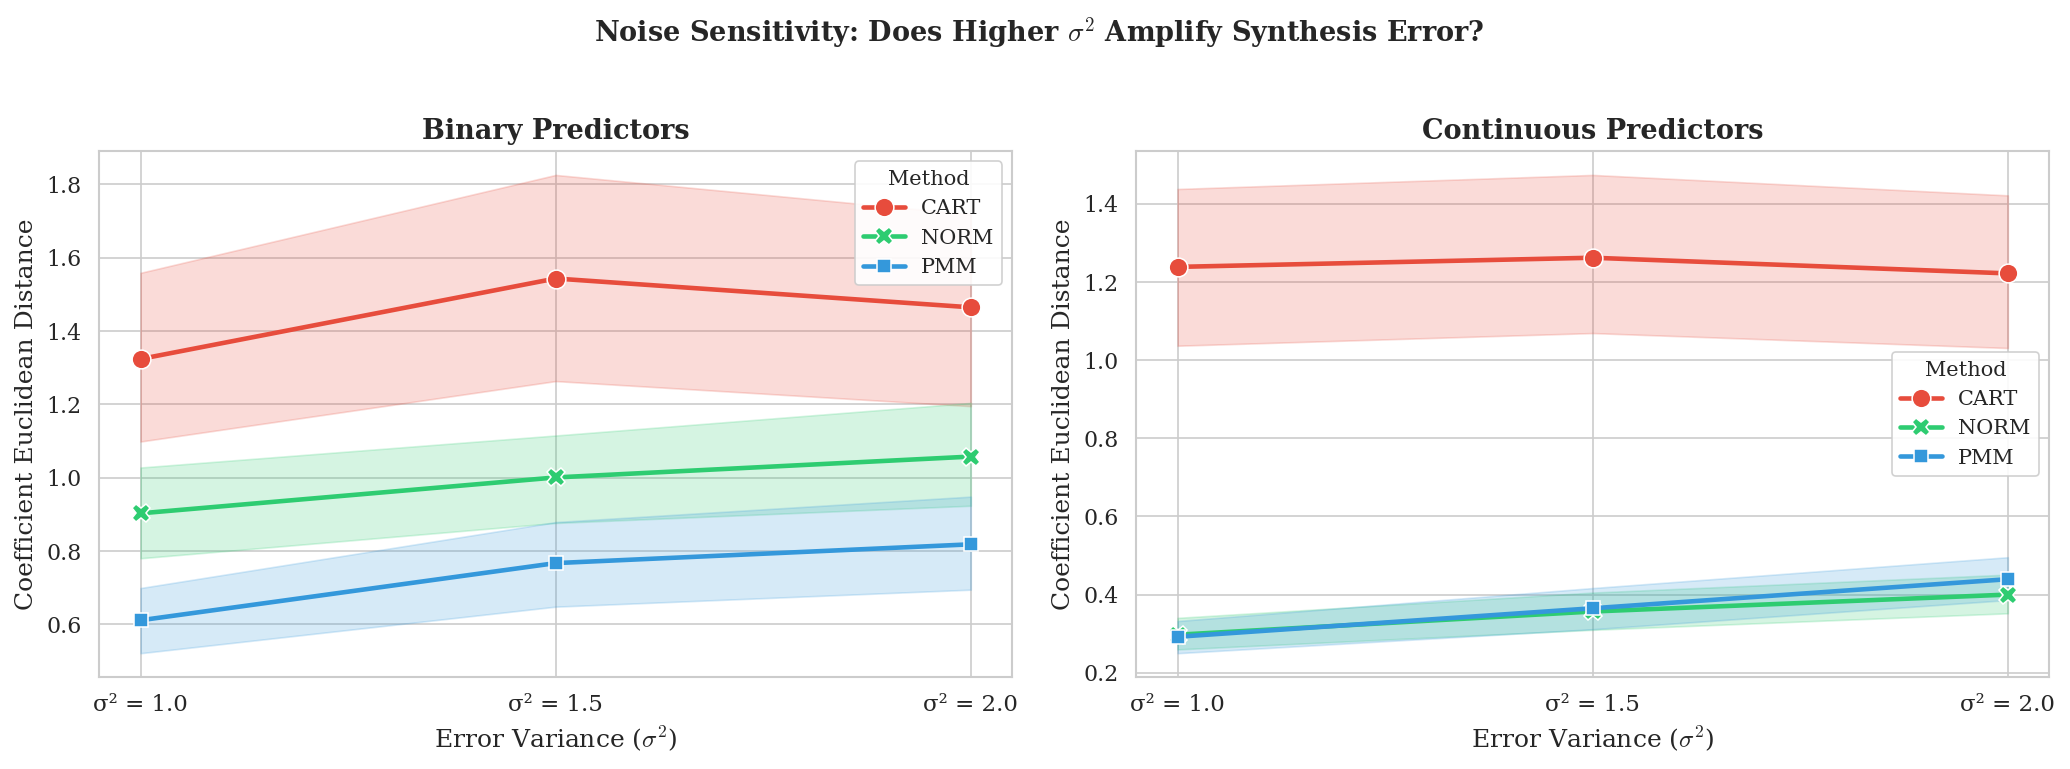

✓ Plot 7 saved.


In [14]:
# ── Plot 7: Noise Sensitivity — Euclidean Distance vs. σ² ───────────────────

plot_df7 = df.dropna(subset=["coef_eucl_dist"]).copy()
plot_df7["Method"]        = plot_df7["method"].str.upper()
plot_df7["Variable Type"] = plot_df7["var_type"].str.capitalize()

n_vtypes = len(VARTYPE_ORDER)
fig, axes = plt.subplots(1, n_vtypes, figsize=(7 * n_vtypes, 5), sharey=False, squeeze=False)
axes = axes.ravel()

for ax, vt in zip(axes, VARTYPE_ORDER):
    subset7 = plot_df7[plot_df7["Variable Type"] == vt]
    sns.lineplot(
        data=subset7,
        x="sigma_2",
        y="coef_eucl_dist",
        hue="Method",
        hue_order=METHOD_ORDER,
        palette=METHOD_PALETTE,
        style="Method",
        markers=True,
        dashes=False,
        errorbar=("ci", 95),
        linewidth=2.2,
        markersize=9,
        ax=ax,
    )
    ax.set_xticks(SIGMA2_VALS)
    ax.set_xticklabels([f"σ² = {v}" for v in SIGMA2_VALS], fontsize=11)
    ax.set_xlabel("Error Variance ($\\sigma^2$)", fontsize=12)
    ax.set_ylabel("Coefficient Euclidean Distance", fontsize=12)
    ax.set_title(f"{vt} Predictors", fontsize=13, fontweight="bold")
    ax.legend(title="Method", fontsize=10, title_fontsize=10, framealpha=0.9)

fig.suptitle(r"Noise Sensitivity: Does Higher $\sigma^2$ Amplify Synthesis Error?",
             fontsize=13, fontweight="bold", y=1.02)

plt.tight_layout()
fig.savefig(os.path.join(fig_dir, "plot7_noise_sensitivity_sigma2.png"))
plt.show()
print("✓ Plot 7 saved.")

---

## Plot 8 — Which Predictors Does CART Fail On? (Per-Predictor Bias Heatmap)

**Research question:** Is CART's coefficient distortion spread evenly across all
predictors, or does it concentrate on specific indices (e.g., large-β predictors)?

For each predictor slot $j = 1 \ldots p$ and each method, the **mean absolute bias**
$$\overline{|\hat{\beta}_{OD,j} - \hat{\beta}_{SD,j}|}$$
is shown as a heatmap (predictors × methods), with separate panels for
`continuous` and `binary` var_type. High colour intensity identifies the
predictor positions where synthesis error concentrates.


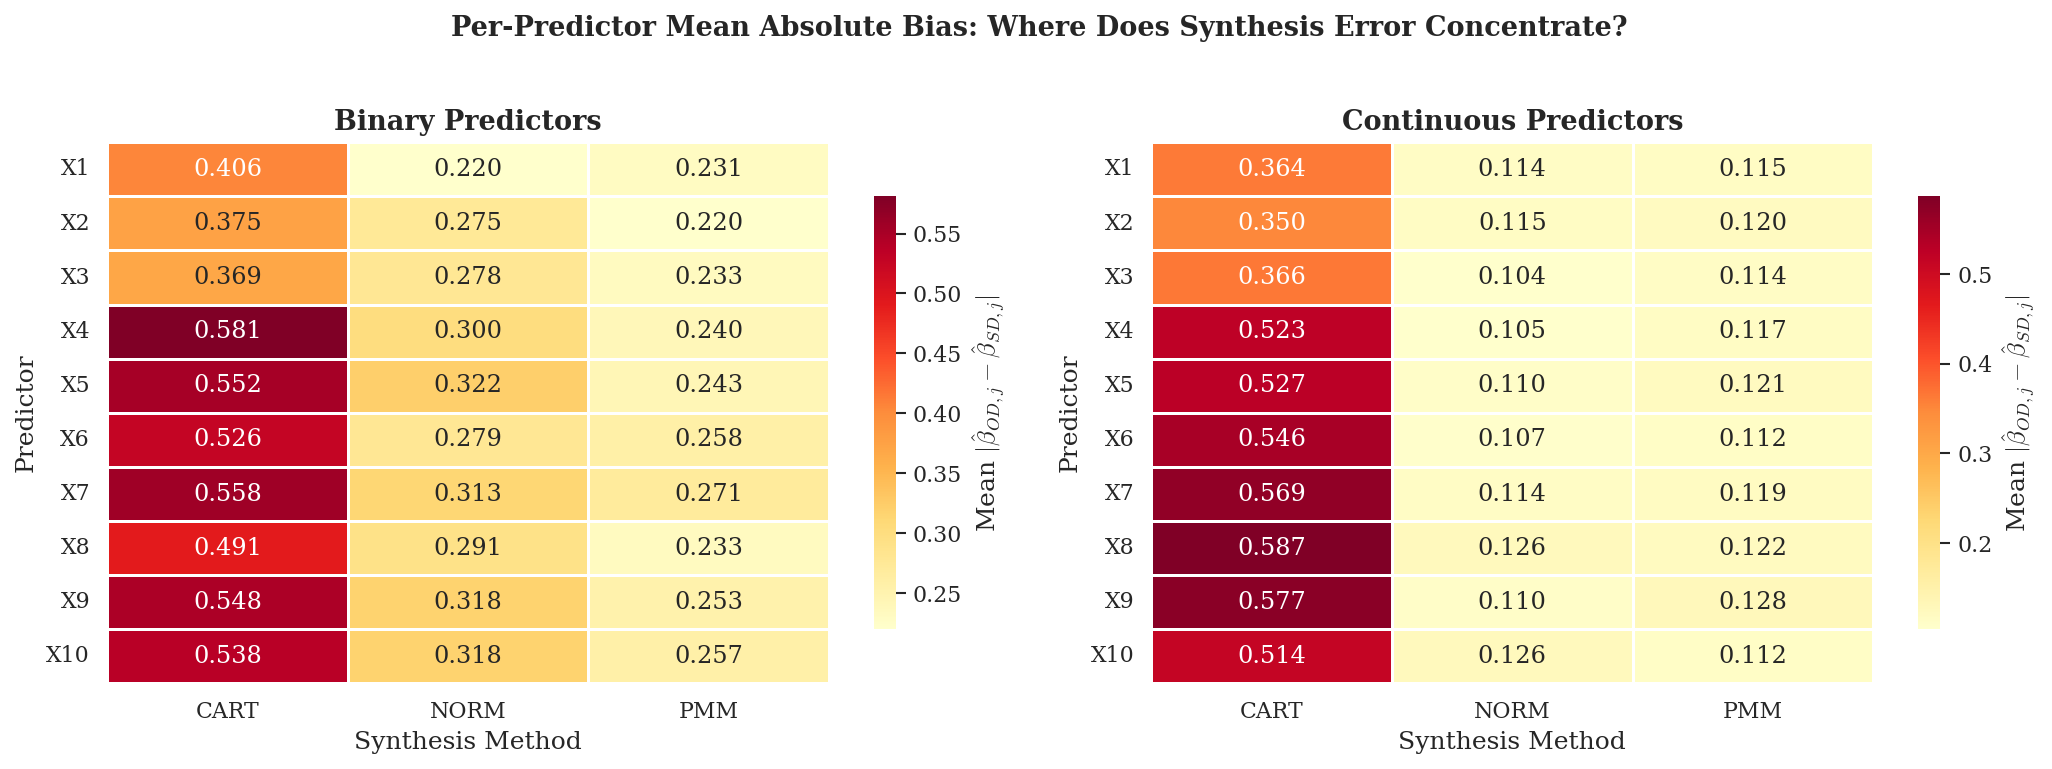

✓ Plot 8 saved.


In [15]:
# ── Plot 8: Per-predictor mean absolute bias heatmap ────────────────────────

beta_od_s = [c for c in df.columns if c.startswith("beta_od_") and c != "beta_od_0"]
beta_sd_s = [c for c in df.columns if c.startswith("beta_sd_") and c != "beta_sd_0"]
n_pred    = len(beta_od_s)

n_vtypes = len(VARTYPE_ORDER)
fig, axes = plt.subplots(1, n_vtypes, figsize=(7 * n_vtypes, 5), squeeze=False)
axes = axes.ravel()

for ax, vt in zip(axes, VAR_TYPES):
    sub = df[df["var_type"] == vt]
    mat = np.full((n_pred, len(METHODS)), np.nan)

    for mi, m in enumerate(METHODS):
        msub = sub[sub["method"] == m]
        bod  = msub[beta_od_s].values
        bsd  = msub[beta_sd_s].values
        abs_bias = np.abs(bod - bsd)
        mat[:, mi] = np.nanmean(abs_bias, axis=0)

    sns.heatmap(
        mat,
        ax=ax,
        xticklabels=METHOD_ORDER,
        yticklabels=[f"X{j+1}" for j in range(n_pred)],
        cmap="YlOrRd",
        annot=True,
        fmt=".3f",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": r"Mean $|\hat{\beta}_{OD,j} - \hat{\beta}_{SD,j}|$", "shrink": 0.8},
    )
    ax.set_title(f"{vt.capitalize()} Predictors", fontsize=13, fontweight="bold")
    ax.set_xlabel("Synthesis Method", fontsize=12)
    ax.set_ylabel("Predictor", fontsize=12)
    ax.tick_params(axis="y", labelrotation=0)

fig.suptitle("Per-Predictor Mean Absolute Bias: Where Does Synthesis Error Concentrate?",
             fontsize=13, fontweight="bold", y=1.02)

plt.tight_layout()
fig.savefig(os.path.join(fig_dir, "plot8_predictor_bias_heatmap.png"))
plt.show()
print("✓ Plot 8 saved.")

---

## Plot 9 — Does More Data Heal the Coverage Collapse? (N × CI Coverage)

**Research question:** Can a simple increase in sample size ($N$) compensate for
CART's structural distortions and restore nominal CI coverage?

A line plot with $N \in \{100, 1000\}$ on the x-axis and CI Coverage Rate on the
y-axis, grouped by method and faceted by `var_type`, reveals whether the synthesis
error is a **finite-sample artefact** (fixable by collecting more data) or a
**systematic structural bias** (persisting regardless of N).


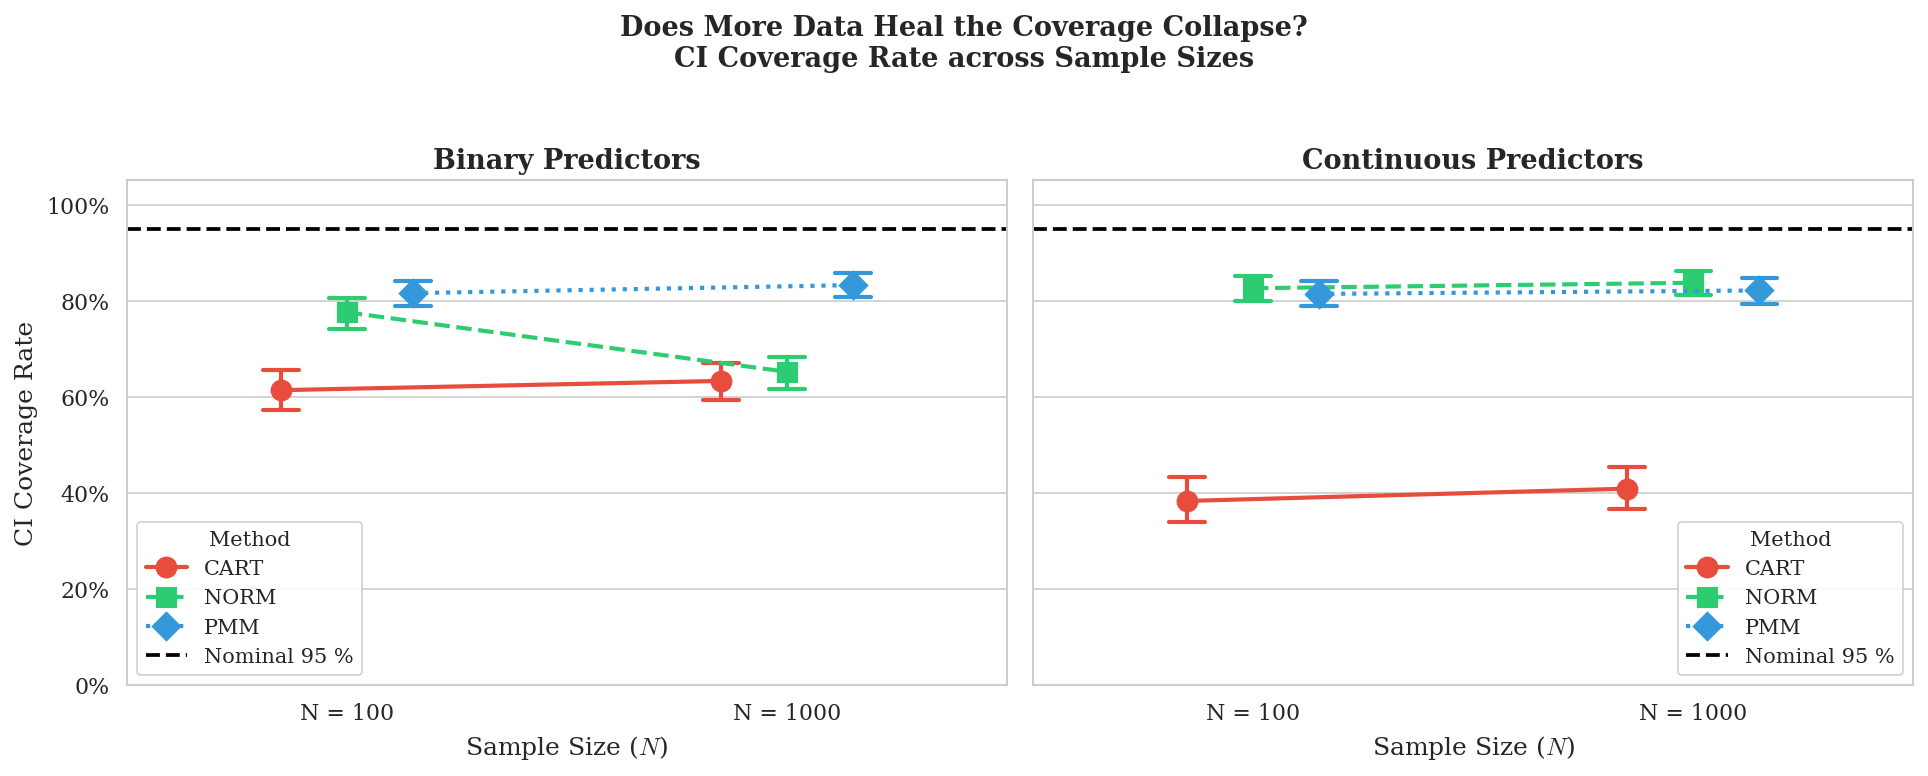

✓ Plot 9 saved.


In [16]:
# ── Plot 9: N × CI Coverage — does more data heal the coverage collapse? ────

cov_df9 = df.dropna(subset=["ci_coverage"]).copy()
cov_df9["Method"]        = cov_df9["method"].str.upper()
cov_df9["Variable Type"] = cov_df9["var_type"].str.capitalize()
cov_df9["N_label"]       = "N = " + cov_df9["N"].astype(str)

N_label_order = [f"N = {n}" for n in N_VALS]

n_vtypes = len(VARTYPE_ORDER)
fig, axes = plt.subplots(1, n_vtypes, figsize=(6.5 * n_vtypes, 5), sharey=True, squeeze=False)
axes = axes.ravel()

for ax, vt in zip(axes, VARTYPE_ORDER):
    subset9 = cov_df9[cov_df9["Variable Type"] == vt]
    sns.pointplot(
        data=subset9,
        x="N_label",
        y="ci_coverage",
        hue="Method",
        hue_order=METHOD_ORDER,
        palette=METHOD_PALETTE,
        order=N_label_order,
        dodge=0.3,
        markers=["o", "s", "D", "^", "v", "P"][:len(METHODS)],
        linestyles=["-", "--", ":", "-.", (0, (3,1,1,1)), (0, (5,2))][:len(METHODS)],
        errorbar=("ci", 95),
        capsize=0.08,
        linewidth=2,
        markersize=9,
        ax=ax,
    )
    ax.axhline(0.95, color="black", linestyle="--", linewidth=1.8, label="Nominal 95 %")
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Sample Size ($N$)", fontsize=12)
    ax.set_ylabel("CI Coverage Rate", fontsize=12)
    ax.set_title(f"{vt} Predictors", fontsize=13, fontweight="bold")
    ax.legend(title="Method", fontsize=10, title_fontsize=10, framealpha=0.9)

fig.suptitle("Does More Data Heal the Coverage Collapse?\n"
             "CI Coverage Rate across Sample Sizes",
             fontsize=13, fontweight="bold", y=1.03)

plt.tight_layout()
fig.savefig(os.path.join(fig_dir, "plot9_N_ci_coverage.png"))
plt.show()
print("✓ Plot 9 saved.")

---

## Plot 10 — Reproduction Fidelity: $\hat{\beta}_{OD}$ vs. $\hat{\beta}_{SD}$ Scatter

**Research question:** Does each synthesis method reproduce the exact coefficient
values, or does it systematically shrink / distort them?

A scatter plot of $\hat{\beta}_{OD,j}$ (x-axis) vs. $\hat{\beta}_{SD,j}$ (y-axis)
for all slopes $j \geq 1$, with one panel per method and colour coding for
`var_type`, directly visualises the magnitude and direction of bias:

* **Perfect synthesis** → all points lie on the `y = x` diagonal.
* **CART's staircase effect** → points cluster around discrete horizontal levels,
  compressed toward zero (the tree's regression-to-mean artefact).
* **NORM / PMM** → points should scatter tightly around the diagonal.


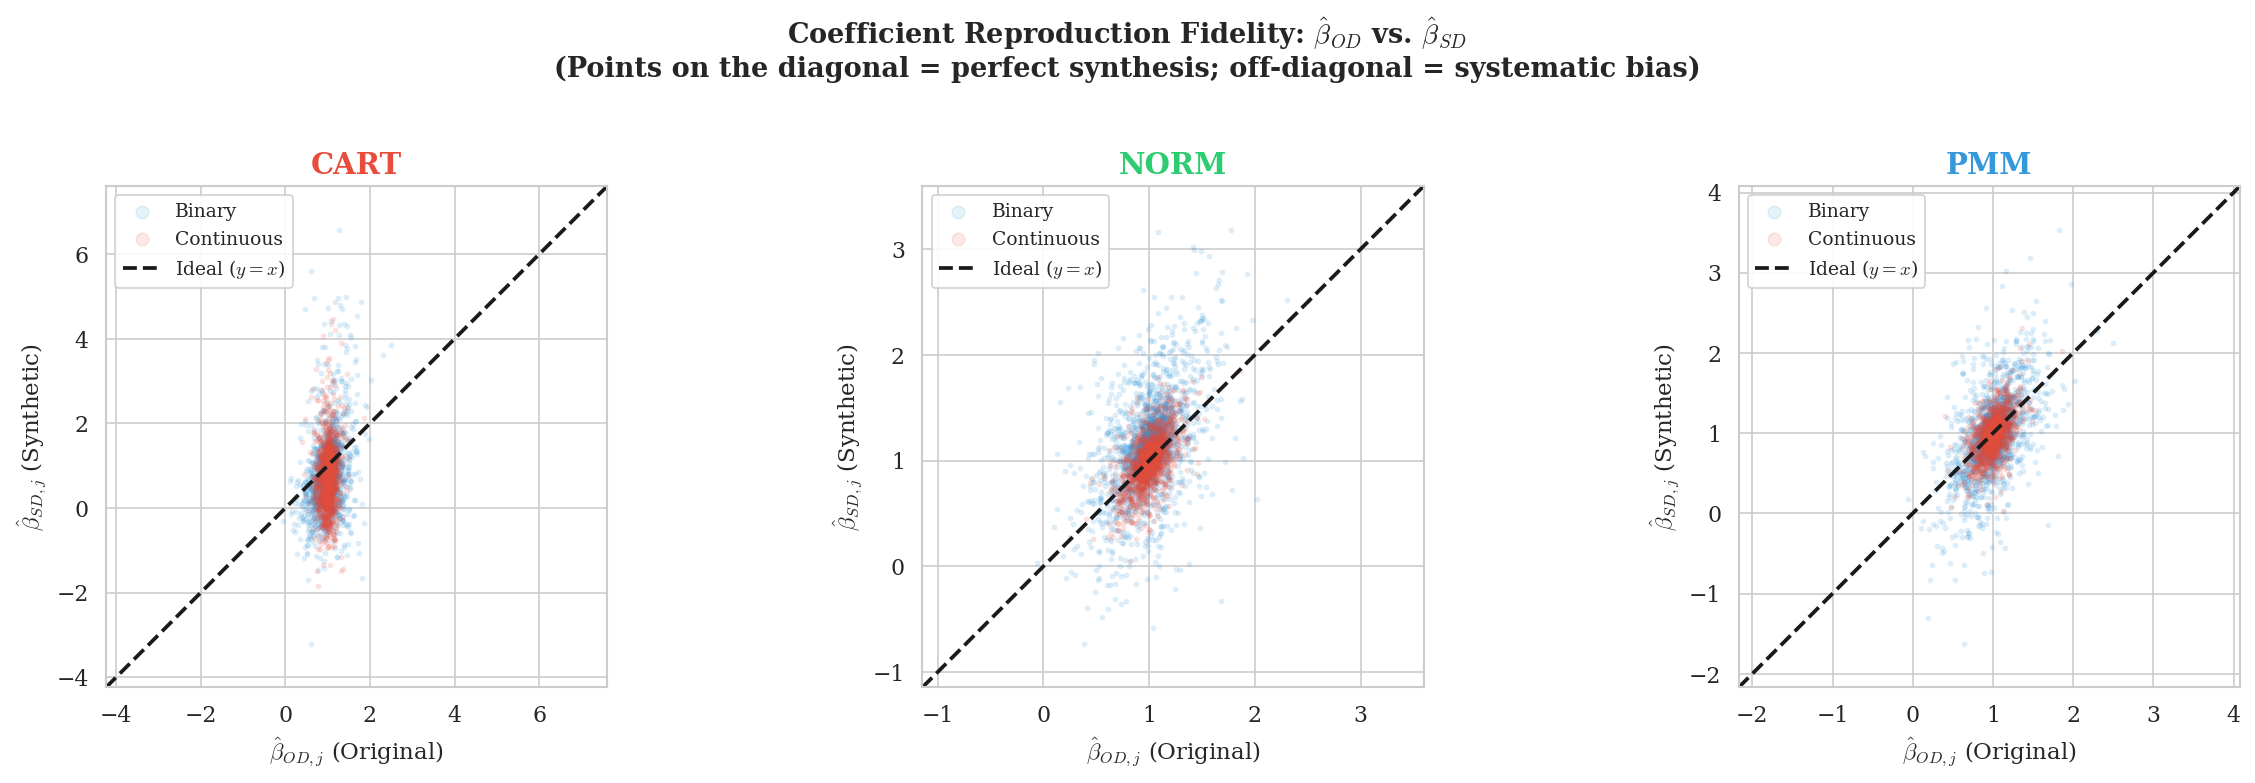

✓ Plot 10 saved.


In [17]:
# ── Plot 10: OD vs SD coefficient scatter (reproduction fidelity) ───────────

beta_od_s10 = [c for c in df.columns if c.startswith("beta_od_") and c != "beta_od_0"]
beta_sd_s10 = [c for c in df.columns if c.startswith("beta_sd_") and c != "beta_sd_0"]

SAMPLE = 20_000
rng    = np.random.default_rng(42)

records = []
for m in METHODS:
    msub = df[df["method"] == m]
    idx  = rng.choice(len(msub), size=min(SAMPLE, len(msub)), replace=False)
    samp = msub.iloc[idx]
    bod  = samp[beta_od_s10].values.ravel()
    bsd  = samp[beta_sd_s10].values.ravel()
    vt   = np.repeat(samp["var_type"].values, len(beta_od_s10))
    keep = ~(np.isnan(bod) | np.isnan(bsd))
    records.append(pd.DataFrame({
        "beta_od": bod[keep],
        "beta_sd": bsd[keep],
        "var_type": vt[keep],
        "Method":  m.upper(),
    }))

scatter_df = pd.concat(records, ignore_index=True)
scatter_df["Variable Type"] = scatter_df["var_type"].str.capitalize()

n_methods = len(METHOD_ORDER)
fig, axes = plt.subplots(1, n_methods, figsize=(5.5 * n_methods, 5), sharey=False, squeeze=False)
axes = axes.ravel()

for ax, m in zip(axes, METHOD_ORDER):
    sdf = scatter_df[scatter_df["Method"] == m]
    for vt in VARTYPE_ORDER:
        vsdf = sdf[sdf["Variable Type"] == vt]
        ax.scatter(
            vsdf["beta_od"], vsdf["beta_sd"],
            c=VARTYPE_PALETTE[vt], alpha=0.12, s=4, rasterized=True, label=vt,
        )
    # y = x reference
    lim_lo = min(ax.get_xlim()[0], ax.get_ylim()[0], sdf["beta_od"].quantile(0.01), sdf["beta_sd"].quantile(0.01))
    lim_hi = max(ax.get_xlim()[1], ax.get_ylim()[1], sdf["beta_od"].quantile(0.99), sdf["beta_sd"].quantile(0.99))
    margin = 0.05 * (lim_hi - lim_lo)
    ref_range = [lim_lo - margin, lim_hi + margin]
    ax.plot(ref_range, ref_range, "k--", linewidth=1.8, label="Ideal ($y=x$)")
    ax.set_xlim(ref_range)
    ax.set_ylim(ref_range)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(m, fontsize=14, fontweight="bold", color=METHOD_PALETTE[m])
    ax.set_xlabel(r"$\hat{\beta}_{OD,j}$ (Original)", fontsize=11)
    ax.set_ylabel(r"$\hat{\beta}_{SD,j}$ (Synthetic)", fontsize=11)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=9, framealpha=0.9,
              markerscale=3)

fig.suptitle(r"Coefficient Reproduction Fidelity: $\hat{\beta}_{OD}$ vs. $\hat{\beta}_{SD}$" + "\n"
             "(Points on the diagonal = perfect synthesis; off-diagonal = systematic bias)",
             fontsize=13, fontweight="bold", y=1.03)

plt.tight_layout()
fig.savefig(os.path.join(fig_dir, "plot10_od_vs_sd_scatter.png"), dpi=300)
plt.show()
print("✓ Plot 10 saved.")

---

## Summary Table

Aggregate all three metrics by **method × var_type** across all scenarios.

In [18]:
# ── Grand summary ───────────────────────────────────────────────────────────
summary = (
    df.dropna(subset=["coef_eucl_dist", "r2_degradation", "sig_agreement_pct"])
      .groupby(["method", "var_type"])
      .agg(
          n = ("coef_eucl_dist", "count"),
          eucl_dist_mean   = ("coef_eucl_dist", "mean"),
          eucl_dist_median = ("coef_eucl_dist", "median"),
          eucl_dist_std    = ("coef_eucl_dist", "std"),
          sig_agree_mean   = ("sig_agreement_pct", "mean"),
          sig_agree_std    = ("sig_agreement_pct", "std"),
          r2_degrad_mean   = ("r2_degradation", "mean"),
          r2_degrad_median = ("r2_degradation", "median"),
          r2_degrad_std    = ("r2_degradation", "std"),
      )
      .round(4)
)

print("=" * 80)
print("GRAND SUMMARY: Synthesis Method Comparison")
print(f"  Methods: {METHOD_ORDER}  |  Var types: {VARTYPE_ORDER}")
print("=" * 80)
display(summary)

summary.to_csv(os.path.join(result_dir, "evaluation_summary.csv"))
print(f"\n✓ Summary saved to results/evaluation_summary.csv")

GRAND SUMMARY: Synthesis Method Comparison
  Methods: ['CART', 'NORM', 'PMM']  |  Var types: ['Binary', 'Continuous']


n  eucl_dist_mean  eucl_dist_median  eucl_dist_std  \
method var_type                                                           
cart   binary      360          1.4438            0.9295         1.4659   
       continuous  360          1.2409            0.8835         1.1247   
norm   binary      360          0.9872            0.8265         0.7215   
       continuous  360          0.3515            0.2516         0.2612   
pmm    binary      360          0.7325            0.5209         0.6357   
       continuous  360          0.3657            0.2553         0.2869   

                   sig_agree_mean  sig_agree_std  r2_degrad_mean  \
method var_type                                                    
cart   binary             80.8519        26.8416          0.0930   
       continuous         81.7870        29.0633          0.2103   
norm   binary             90.6389        16.0814          0.0435   
       continuous         99.2778         3.8588          0.0230   
pmm    binary             89.5556        16.4466          0.0345   
       continuous         99.0463         4.4211          0.0253   

                   r2_degrad_median  r2_degrad_std  
method var_type                                     
cart   binary                0.0604         0.0926  
       continuous            0.1610         0.1781  
norm   binary                0.0308         0.0421  
       continuous            0.0101         0.0333  
pmm    binary                0.0207         0.0403  
       continuous            0.0107         0.0421


✓ Summary saved to results/evaluation_summary.csv


In [19]:
# ── Key findings for thesis (auto-generated from config) ─────────────────────

print("KEY FINDINGS")
print("=" * 60)

# Per method × var_type: median Euclidean distance
medians = (
    df.dropna(subset=["coef_eucl_dist"])
      .groupby(["method", "var_type"])["coef_eucl_dist"]
      .median()
)

for i, vt in enumerate(VAR_TYPES, 1):
    vt_cap = vt.capitalize()
    print(f"\n{i}. {vt_cap} predictors — median Euclidean distance:")
    vals = {}
    for m in METHODS:
        try:
            val = medians.loc[(m, vt)]
        except KeyError:
            val = float("nan")
        vals[m] = val
        print(f"   {m.upper()}: {val:.3f}", end="")
    print()

    # Compare all pairs: how much worse is each method relative to the best
    best_method = min(vals, key=vals.get)
    best_val = vals[best_method]
    for m in METHODS:
        if m != best_method and best_val > 0:
            print(f"   → {m.upper()} is {vals[m] / best_val:.1f}× relative to {best_method.upper()}")

# Cross var_type comparison for each method
print(f"\n{len(VAR_TYPES) + 1}. Within-method performance ratio across var_types:")
for m in METHODS:
    vt_vals = {}
    for vt in VAR_TYPES:
        try:
            vt_vals[vt] = medians.loc[(m, vt)]
        except KeyError:
            vt_vals[vt] = float("nan")
    worst_vt = max(vt_vals, key=vt_vals.get)
    best_vt  = min(vt_vals, key=vt_vals.get)
    if vt_vals[best_vt] > 0:
        ratio = vt_vals[worst_vt] / vt_vals[best_vt]
        print(f"   {m.upper()}: {ratio:.1f}× worse on {worst_vt} vs {best_vt}")

print("\n✓ Notebook 04 complete.")

KEY FINDINGS

1. Binary predictors — median Euclidean distance:
   CART: 0.930   NORM: 0.827   PMM: 0.521
   → CART is 1.8× relative to PMM
   → NORM is 1.6× relative to PMM

2. Continuous predictors — median Euclidean distance:
   CART: 0.883   NORM: 0.252   PMM: 0.255
   → CART is 3.5× relative to NORM
   → PMM is 1.0× relative to NORM

3. Within-method performance ratio across var_types:
   CART: 1.1× worse on binary vs continuous
   NORM: 3.3× worse on binary vs continuous
   PMM: 2.0× worse on binary vs continuous

✓ Notebook 04 complete.
